# Atelier Préparation de Données Images

## Contexte 
Une entreprise souhaite développer un système d’intelligence artificielle capable de reconnaître 
automatiquement le type de déchet présent sur une photographie afin d'améliorer le tri des 
déchets. 
Le modèle devra classer chaque image dans l'une des catégories suivantes : 
 cardboard : cartons ondulés, cartons plats, … 
 plastic : bouteilles, emballages plastiques... 
 paper : feuilles,  journaux... 
 glass : bouteilles et objets en verre... 
 metal : canettes, boîtes métalliques... 
 trash : emballages bonbons, tasses jetables, ... 
Le problème est que les images collectées proviennent de plusieurs sources. Elles ne sont donc pas 
homogènes : dimensions différentes ; formats différents ; images RGB et grayscale ; certaines images 
sont trop petites ; certaines images sont corrompues ; quelques images sont vides ; images 
dupliquées ; quelques images placées dans le mauvais dossier ; classes déséquilibrées. 
L'objectif de l'atelier est donc de construire un jeu de données images propre et homogène, prêt à 
être utilisé pour entraîner un modèle de Machine Learning ou de Deep Learning.

## Objectifs pédagogiques 
À la fin de l'atelier, l'apprenant devra être capable de : 
1) explorer un dataset d'images ; 
2) détecter les images problématiques ; 
3) détecter les différences de résolution ; 
4) détecter les différences de nombre de canaux ; 
5) identifier les images trop petites ; 
6) détecter les doublons ; 
7) identifier les classes déséquilibrées ; 
8) redimensionner les images ; 
9) normaliser les valeurs des pixels ; 
10) uniformiser les canaux ;  
11) appliquer de la data augmentation 

### Partie 1:  Exploration du dataset 

Développer un programme Python capable de récupérer, pour chaque image, son nom, sa classe, 
son format, son mode, sa largeur, sa hauteur, l’écart-type de ses pixels, son nombre de canaux et sa 
taille. 
NB : prendre en charge aussi les fichiers corrompus

#### Importation

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image

RAW_DIR = Path("../data/raw")

#### Fonction pour analyser une image

In [2]:
def analyser_image(chemin):
    info = {
        "nom": chemin.name,
        "classe": chemin.parent.name,
        "taille_ko": round(chemin.stat().st_size / 1024, 2),
        "corrompue": False,
    }
    try:
        img = Image.open(chemin)
        img.load()
        info["format"] = img.format
        info["mode"] = img.mode
        info["largeur"] = img.width
        info["hauteur"] = img.height
        info["nb_canaux"] = len(img.getbands())
        info["std_pixels"] = round(float(np.array(img.convert("L")).std()), 2)
    except Exception:
        info["corrompue"] = True
    return info

#### Boucle sur toutes les images

In [3]:
lignes = []
for chemin in RAW_DIR.rglob("*"):
    if chemin.is_file():
        lignes.append(analyser_image(chemin))

df = pd.DataFrame(lignes)
df.head()

,nom,classe,taille_ko,corrompue,format,mode,largeur,hauteur,nb_canaux,std_pixels
0,metal26 (5).jpg,metal,1.63,False,JPEG,RGB,40.0,40.0,3.0,57.63
1,metal47 (5).jpg,metal,12.91,False,JPEG,RGB,512.0,384.0,3.0,61.73
2,metal20 (5).jpg,metal,21.61,False,JPEG,RGB,512.0,384.0,3.0,65.92
3,metal140 (5).jpg,metal,18.73,False,JPEG,RGB,512.0,384.0,3.0,51.69
4,metal51 (5).jpg,metal,11.60,False,JPEG,RGB,512.0,384.0,3.0,46.75


#### Vérification des résultats

In [5]:
print(df.shape)
print("------------------------------")
print(df["corrompue"].sum())
print("------------------------------")
print(df["mode"].value_counts(dropna=False))

(1032, 10)
------------------------------
6
------------------------------
mode
RGB     1006
RGBA      18
NaN        6
P          2
Name: count, dtype: int64


### Partie 2: Détecter les images corrompues

### Écrire et se servir d’une fonction qui détecte une image corrompue.

#### La fonction

In [6]:
def est_corrompue(chemin):
    try:
        with Image.open(chemin) as img:
            img.verify()
        with Image.open(chemin) as img:
            img.load()
        return False
    except Exception:
        return True

#### Utilisation sur toutes les images

In [7]:
df["corrompue"] = [
    est_corrompue(RAW_DIR / classe / nom)
    for classe, nom in zip(df["classe"], df["nom"])
]

#### Affichage des images corrompues

In [8]:
print("Images corrompues :", df["corrompue"].sum())
df[df["corrompue"]][["nom", "classe"]]

Images corrompues : 6


,nom,classe
47,metal48 (5).jpg,metal
354,plastic13 (5).jpg,plastic
604,paper213 (5).jpg,paper
663,trash3 (5).jpg,trash
680,glass74 (5).jpg,glass
925,cardboard83 (6).jpg,cardboard


### Partie 3: Détecter les images vides 

Écrire et se servir d’une fonction qui détecte les images vides : image entièrement noire, image 
entièrement blanche ou image dont les pixels présentent très peu de variation. 

#### La fonction

In [11]:
def est_vide(chemin, seuil_std=5):
    try:
        gris = np.array(Image.open(chemin).convert("L"))
    except Exception:
        return False
    return gris.std() < seuil_std

#### Application à toutes les images

In [12]:
df["vide"] = [
    est_vide(RAW_DIR / classe / nom)
    for classe, nom in zip(df["classe"], df["nom"])
]
print("Images vides :", df["vide"].sum())
df[df["vide"]][["nom", "classe", "std_pixels"]]

Images vides : 4


,nom,classe,std_pixels
56,image-blanche-512x384 (6).jpg,metal,1.13
88,image-noire-512x384 (7).png,metal,0.00
705,image-noire-512x384 (6).png,glass,0.00
964,image-blanche-512x384 (5).jpg,cardboard,1.13


#### Vérification du seuil

In [13]:
df.sort_values("std_pixels").head(10)[["nom", "classe", "std_pixels"]]

,nom,classe,std_pixels
88,image-noire-512x384 (7).png,metal,0.00
705,image-noire-512x384 (6).png,glass,0.00
964,image-blanche-512x384 (5).jpg,cardboard,1.13
56,image-blanche-512x384 (6).jpg,metal,1.13
201,plastic150 (5).jpg,plastic,7.49
342,plastic3 (5).jpg,plastic,7.98
190,plastic147 (5).jpg,plastic,8.41
285,plastic2 (5).jpg,plastic,8.59
260,plastic12 (5).jpg,plastic,9.26
708,glass178 (5).jpg,glass,9.75


### Partie 4: Détecter les différences de résolution

### 1) Déterminer la résolution minimale, la résolution maximale, les résolutions les plus fréquentes et le nombre d'images par résolution. 

In [15]:
df_ok = df[~df["corrompue"]].copy()
df_ok["resolution"] = df_ok["largeur"].astype(int).astype(str) + "x" + df_ok["hauteur"].astype(int).astype(str)
df_ok["nb_pixels"] = df_ok["largeur"] * df_ok["hauteur"]

In [16]:
print("Résolution minimale :", df_ok.loc[df_ok["nb_pixels"].idxmin(), "resolution"])
print("Résolution maximale :", df_ok.loc[df_ok["nb_pixels"].idxmax(), "resolution"])

comptage = df_ok["resolution"].value_counts()
print("Nombre de résolutions différentes :", len(comptage))
comptage.head(10)

Résolution minimale : 32x32
Résolution maximale : 512x384
Nombre de résolutions différentes : 4


resolution
512x384    1013
32x32         5
40x40         4
48x32         4
Name: count, dtype: int64

### 2) On décide qu'une image doit avoir au minimum 64 × 64 pixels. Identifier toutes les images ne respectant pas cette contrainte. 

In [17]:
df_ok["trop_petite"] = (df_ok["largeur"] < 64) | (df_ok["hauteur"] < 64)
print("Images trop petites :", df_ok["trop_petite"].sum())
df_ok[df_ok["trop_petite"]][["nom", "classe", "resolution"]]

Images trop petites : 13


,nom,classe,resolution
0,metal26 (5).jpg,metal,40x40
50,metal2 (5).jpg,metal,32x32
83,metal121 (5).jpg,metal,48x32
412,paper64 (5).jpg,paper,48x32
431,paper10 (3).jpg,paper,32x32
469,paper54 (5).jpg,paper,40x40
754,glass100 (5).jpg,glass,40x40
764,glass23 (5).jpg,glass,32x32
804,glass21 (5).jpg,glass,32x32
807,glass15 (5).jpg,glass,48x32


### Partie 5: Partie 5 – Détecter les différents canaux 

Déterminer le nombre d'images selon leur nombre de canaux.

#### Nombre d"images par nombre de canaux

In [19]:
df_ok["nb_canaux"].value_counts()

nb_canaux
3.0    1006
4.0      18
1.0       2
Name: count, dtype: int64

#### Croisement

In [20]:
pd.crosstab(df_ok["mode"], df_ok["nb_canaux"])

nb_canaux,1.0,3.0,4.0
mode,,,
P,2,0,0
RGB,0,1006,0
RGBA,0,0,18


### Partie 6: Détecter les doublons 

Écrire et se servir d’une fonction qui détecte les doublons 
NB : Deux fichiers différents peuvent contenir exactement la même image. 

Un hash est une « empreinte digitale » calculée à partir du contenu : deux images identiques donnent le même hash, et deux images différentes donnent (presque toujours) des hashs différents. On calcule un hash par image, puis on cherche les hashs qui apparaissent plusieurs fois.

Je calcule le hash sur les pixels (et non sur le fichier brut), ce qui détecte aussi une même image enregistrée dans deux formats différents.

#### Fonction permettant d'avoir le hash

In [21]:
import hashlib

def calculer_hash(chemin):
    try:
        with Image.open(chemin) as img:
            contenu = img.convert("RGB").tobytes() + str(img.size).encode()
            return hashlib.md5(contenu).hexdigest()
    except Exception:
        return None

#### Détection des doublons

In [22]:
df["hash"] = [
    calculer_hash(RAW_DIR / classe / nom)
    for classe, nom in zip(df["classe"], df["nom"])
]
df["doublon"] = df["hash"].notna() & df.duplicated(subset="hash", keep="first")

print("Doublons :", df["doublon"].sum())

Doublons : 15


#### Répérage des groupes de doublons

In [23]:
groupes = df[df["hash"].notna() & df.duplicated(subset="hash", keep=False)]
groupes.sort_values("hash")[["nom", "classe", "hash"]]

,nom,classe,hash
332,plastic171az (5).jpg,plastic,12f5e08f157eda53047567d8c67525a5
248,plastic171 (5).jpg,plastic,12f5e08f157eda53047567d8c67525a5
290,plastic140 (5).jpg,plastic,16670e41cd1550fa0db56ee9e7882ded
287,plastic140y (5).jpg,plastic,16670e41cd1550fa0db56ee9e7882ded
323,plasticx199 (5).jpg,plastic,1b3b431ee3e81d7ae208c1c282601424
265,plastic199 (5).jpg,plastic,1b3b431ee3e81d7ae208c1c282601424
446,paper77ty (5).jpg,paper,21ba88c5d3a38f048a8f1136d6608ed1
410,paper77 (5).jpg,paper,21ba88c5d3a38f048a8f1136d6608ed1
56,image-blanche-512x384 (6).jpg,metal,8829a3e854f463eded52dbc1e7252d37
964,image-blanche-512x384 (5).jpg,cardboard,8829a3e854f463eded52dbc1e7252d37


### Partie 7: Détecter les images mal classées

On procède en deux temps :

* **Candidats forts (automatique):** Les doublons inter-classes détectés à la Partie 6 sont quasiment toujours des erreurs de tri (la même image ne peut logiquement appartenir qu'à une seule classe).

* **Outil de contrôle visuel :** une fonction d'affichage en grille pour parcourir chaque classe par lots et repérer les intrus à l'œil.

#### Candidats forts (automatique)

In [40]:
dup = df[df["hash"].notna() & df.duplicated("hash", keep=False)]
inter = dup.groupby("hash").filter(lambda g: g["classe"].nunique() > 1)
inter.sort_values("hash")[["nom", "classe"]]

,nom,classe
56,image-blanche-512x384 (6).jpg,metal
964,image-blanche-512x384 (5).jpg,cardboard
819,image-violet-512x384 (8).gif,glass
981,image-violet-512x384 (7).gif,cardboard
88,image-noire-512x384 (7).png,metal
705,image-noire-512x384 (6).png,glass
299,plastic152 (5).jpg,plastic
806,glass176 (5).jpg,glass
132,metal91 (5).jpg,metal
692,glass115 (5).jpg,glass


#### Outil de controle visuel

In [41]:
import matplotlib.pyplot as plt

def grille(paires, colonnes=10):
    lignes = (len(paires) + colonnes - 1) // colonnes
    plt.figure(figsize=(20, 2.5 * lignes))
    for i, (classe, nom) in enumerate(paires):
        plt.subplot(lignes, colonnes, i + 1)
        plt.imshow(Image.open(RAW_DIR / classe / nom).convert("RGB"))
        plt.title(f"{classe}\n{nom[:14]}", fontsize=7)
        plt.axis("off")
    plt.show()

def afficher(classe, debut=0):
    d = df[(df["classe"] == classe) & (~df["corrompue"])].iloc[debut:debut + 40]
    grille(list(zip(d["classe"], d["nom"])))

#### Regarder les candidats, puis parcourir les classes

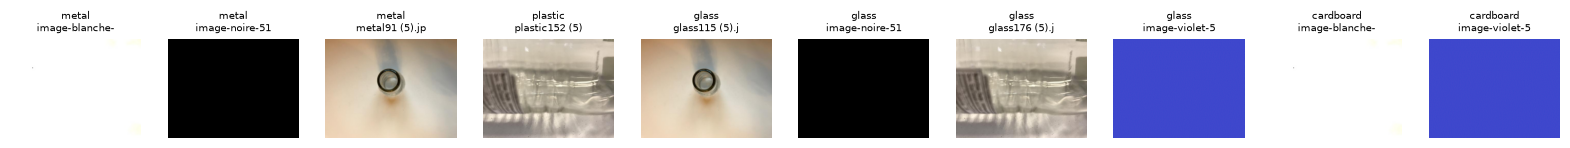

In [42]:
grille(list(zip(inter["classe"], inter["nom"])))   # les candidats forts

#### Rapport final

In [52]:
from IPython.display import Markdown, display

# 1) Tes constats visuels : (racine du nom, classe actuelle, contenu, classe correcte)
constats = [
    ("cardboard161", "cardboard", "Bocal en verre (vue du dessus)", "glass"),
    ("cardboard86d", "cardboard", "Bouteille plastique, bouchon vert", "plastic"),
    ("glass12er", "glass", "Publicité de magazine", "paper"),
    ("metal111", "metal", "Bouteille d'huile d'olive en verre", "glass"),
    ("paper201", "paper", "Objet en cuir/métal", "metal"),
    ("plastic112", "plastic", "Bouteille avec bord en verre visible", "glass"),
]

intrus = []
for racine, classe, contenu, correcte in constats:
    trouves = df[(df["classe"] == classe) & df["nom"].str.startswith(racine)]["nom"].tolist()
    print(racine, "→", trouves)
    for nom in trouves:
        intrus.append({"fichier": nom, "classe_actuelle": classe, "contenu": contenu,
                       "action": "reclasser", "classe_correcte": correcte})

# 2) Images artificielles (noires, blanches, violettes)
autres = df[~df.apply(lambda l: l["nom"].startswith(l["classe"]), axis=1)]
for _, l in autres.iterrows():
    intrus.append({"fichier": l["nom"], "classe_actuelle": l["classe"],
                   "contenu": "Image artificielle (pas un déchet)", "action": "retirer", "classe_correcte": "-"})

# 3) Doublons présents dans deux classes
deja = {i["fichier"] for i in intrus}
for _, l in inter.iterrows():
    if l["nom"] not in deja:
        intrus.append({"fichier": l["nom"], "classe_actuelle": l["classe"],
                       "contenu": "Doublon présent dans deux classes (image ambiguë)",
                       "action": "retirer", "classe_correcte": "-"})

# 4) Colonne pour l'audit
df["mal_classee"] = df["nom"].isin([i["fichier"] for i in intrus])
print("À reclasser :", sum(i["action"] == "reclasser" for i in intrus))
print("Images mal classées :", df["mal_classee"].sum())

# 5) Rapport
tableau = ["| Fichier | Classe actuelle | Contenu réel | Action | Classe correcte |",
           "|---|---|---|---|---|"]
for i in intrus:
    tableau.append(f"| `{i['fichier']}` | {i['classe_actuelle']} | {i['contenu']} | {i['action']} | {i['classe_correcte']} |")

rapport = f"""## Méthodologie

1. **Candidats automatiques** : les doublons présents dans des classes différentes (Partie 6) sont quasiment toujours des erreurs de tri.
2. **Contrôle visuel** : parcours de chaque classe en mosaïques de 40 images.
3. **Décision** : reclassement si la vraie classe est certaine, retrait si l'image est douteuse ou n'est pas un déchet.

## Intrus identifiés

{chr(10).join(tableau)}

## Limites

Le contrôle visuel est subjectif et peut laisser passer un intrus visuellement proche de sa classe. Les cas ambigus sont retirés plutôt que reclassés. Le dossier `raw/` n'est pas modifié : les actions seront appliquées dans `cleaned/` (Partie 9).
"""

display(Markdown(rapport))

cardboard161 → ['cardboard161 (6).jpg']
cardboard86d → ['cardboard86d (6).jpg']
glass12er → ['glass12er (5).jpg']
metal111 → ['metal111 (5).jpg']
paper201 → ['paper201 (5).jpg']
plastic112 → ['plastic112 (5).jpg']
À reclasser : 6
Images mal classées : 16


## Méthodologie

1. **Candidats automatiques** : les doublons présents dans des classes différentes (Partie 6) sont quasiment toujours des erreurs de tri.
2. **Contrôle visuel** : parcours de chaque classe en mosaïques de 40 images.
3. **Décision** : reclassement si la vraie classe est certaine, retrait si l'image est douteuse ou n'est pas un déchet.

## Intrus identifiés

| Fichier | Classe actuelle | Contenu réel | Action | Classe correcte |
|---|---|---|---|---|
| `cardboard161 (6).jpg` | cardboard | Bocal en verre (vue du dessus) | reclasser | glass |
| `cardboard86d (6).jpg` | cardboard | Bouteille plastique, bouchon vert | reclasser | plastic |
| `glass12er (5).jpg` | glass | Publicité de magazine | reclasser | paper |
| `metal111 (5).jpg` | metal | Bouteille d'huile d'olive en verre | reclasser | glass |
| `paper201 (5).jpg` | paper | Objet en cuir/métal | reclasser | metal |
| `plastic112 (5).jpg` | plastic | Bouteille avec bord en verre visible | reclasser | glass |
| `image-blanche-512x384 (6).jpg` | metal | Image artificielle (pas un déchet) | retirer | - |
| `image-noire-512x384 (7).png` | metal | Image artificielle (pas un déchet) | retirer | - |
| `image-noire-512x384 (6).png` | glass | Image artificielle (pas un déchet) | retirer | - |
| `image-violet-512x384 (8).gif` | glass | Image artificielle (pas un déchet) | retirer | - |
| `image-blanche-512x384 (5).jpg` | cardboard | Image artificielle (pas un déchet) | retirer | - |
| `image-violet-512x384 (7).gif` | cardboard | Image artificielle (pas un déchet) | retirer | - |
| `metal91 (5).jpg` | metal | Doublon présent dans deux classes (image ambiguë) | retirer | - |
| `plastic152 (5).jpg` | plastic | Doublon présent dans deux classes (image ambiguë) | retirer | - |
| `glass115 (5).jpg` | glass | Doublon présent dans deux classes (image ambiguë) | retirer | - |
| `glass176 (5).jpg` | glass | Doublon présent dans deux classes (image ambiguë) | retirer | - |

## Limites

Le contrôle visuel est subjectif et peut laisser passer un intrus visuellement proche de sa classe. Les cas ambigus sont retirés plutôt que reclassés. Le dossier `raw/` n'est pas modifié : les actions seront appliquées dans `cleaned/` (Partie 9).


## Partie 8 : Analyser le déséquilibre des classes

Déterminer le nombre d'images par classe

In [53]:
comptage_classes = df["classe"].value_counts()
comptage_classes

classe
paper        252
plastic      224
glass        188
cardboard    169
metal        149
trash         50
Name: count, dtype: int64

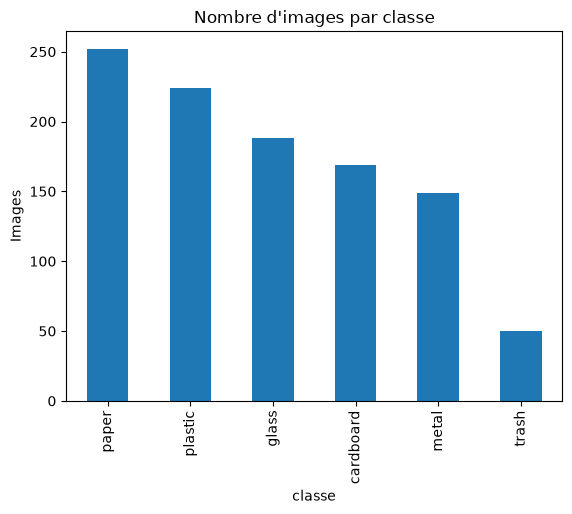

Ratio classe la plus grande / classe la plus petite : 5.0


In [54]:
import matplotlib.pyplot as plt

comptage_classes.plot(kind="bar", title="Nombre d'images par classe")
plt.ylabel("Images")
plt.show()

ratio = comptage_classes.max() / comptage_classes.min()
print(f"Ratio classe la plus grande / classe la plus petite : {ratio:.1f}")

### Audit générale

In [55]:
audit = {
    "Total d'images": len(df),
    "Images corrompues": int(df["corrompue"].sum()),
    "Images quasi vides": int(df["vide"].sum()),
    "Images trop petites": int(df_ok["trop_petite"].sum()),
    "Doublons": int(df["doublon"].sum()),
    "Images grayscale": int((df["mode"] == "L").sum()),
    "Images RGBA": int((df["mode"] == "RGBA").sum()),
    "Images mal classées": int(df["mal_classee"].sum()),
}

audit_df = pd.DataFrame(list(audit.items()), columns=["Indicateur", "Valeur"])
audit_df.to_csv("../reports/audit_images.csv", index=False)
audit_df

,Indicateur,Valeur
0,Total d'images,1032
1,Images corrompues,6
2,Images quasi vides,4
3,Images trop petites,13
4,Doublons,15
5,Images grayscale,0
6,Images RGBA,18
7,Images mal classées,16


## Partie 9 : Redimensionnement 

Redimensionner toutes les images à 224 × 224. 
NB : Redimensionnement avec conservation des proportions et ajout éventuel de padding

### Choix des images à garder

In [56]:
classes = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]

df["trop_petite"] = (df["largeur"] < 64) | (df["hauteur"] < 64)

retirer = {i["fichier"] for i in intrus if i["action"] == "retirer"}
reclasser = {i["fichier"]: i["classe_correcte"] for i in intrus if i["action"] == "reclasser"}

garder = df[
    ~df["corrompue"] & ~df["vide"] & ~df["doublon"] & ~df["trop_petite"]
    & ~df["nom"].isin(retirer)
].copy()

garder["classe_finale"] = garder["nom"].map(reclasser).fillna(garder["classe"])

print("Images gardées :", len(garder))
garder["classe_finale"].value_counts()

Images gardées : 993


classe_finale
paper        245
plastic      218
glass        181
cardboard    161
metal        139
trash         49
Name: count, dtype: int64

### Créer cleaned/ et redimensionner

In [59]:
from PIL import ImageOps

CLEAN_DIR = Path("../data/cleaned")
for c in classes:
    (CLEAN_DIR / c).mkdir(parents=True, exist_ok=True)

for _, l in garder.iterrows():
    img = Image.open(RAW_DIR / l["classe"] / l["nom"]).convert("RGB")
    img = ImageOps.pad(img, (224, 224), color="black")
    img.save(CLEAN_DIR / l["classe_finale"] / l["nom"])

## Partie 10: Uniformisation des canaux

Convertir toutes les images en RGB

In [60]:
nb_converties = 0
for f in CLEAN_DIR.rglob("*"):
    if f.is_file():
        with Image.open(f) as img:
            if img.mode == "RGB":
                continue
            rgb = img.convert("RGB")
        rgb.save(f)
        nb_converties += 1

print("Images converties à cette étape :", nb_converties)

Images converties à cette étape : 0


In [61]:
from collections import Counter

fichiers = [f for f in CLEAN_DIR.rglob("*") if f.is_file()]
print(Counter(Image.open(f).mode for f in fichiers))
print(Counter(len(Image.open(f).getbands()) for f in fichiers))

Counter({'RGB': 993})
Counter({3: 993})
